# Forward Euler convergence on the test ODE

Companion notebook for Section 5.1 (Convergence) of `Lec5.tex`. We solve the test ODE
$$
\frac{du}{dt} = \lambda u, \qquad u(0) = c, \qquad t > 0,
$$
with $\lambda = -0.8$ using the forward Euler method
$$
u_{n+1} = u_n + \lambda u_n \, \Delta t = (1 + \lambda \Delta t) u_n,
$$
at three different time steps $\Delta t$, and compare against the exact solution $u(t) = c e^{\lambda t}$.
As $\Delta t \to 0$ the numerical solution should approach the exact solution — this is the empirical
picture of convergence described in the text.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# parameters
lam = -0.8
c = 1.0
T = 10.0

# three time steps, from coarse to fine, to illustrate convergence
delta_ts = [1.2, 0.6, 0.2]

In [3]:
def forward_euler_test_ode(c, lam, delta_t, N):
    u = np.empty(N + 1)
    u[0] = c
    for n in range(N):
        u[n + 1] = u[n] + lam * u[n] * delta_t
    return u


def exact_test_ode(c, lam, t):
    return c * np.exp(lam * t)

In [4]:
# solve with forward Euler at each time step and record the pointwise error
results = {}
for delta_t in delta_ts:
    N = int(round(T / delta_t))
    t = np.arange(N + 1) * delta_t
    u_fe = forward_euler_test_ode(c, lam, delta_t, N)
    u_exact = exact_test_ode(c, lam, t)
    err = np.abs(u_exact - u_fe)
    results[delta_t] = (t, u_fe, err)

saved test_ode_convergence_solution.png


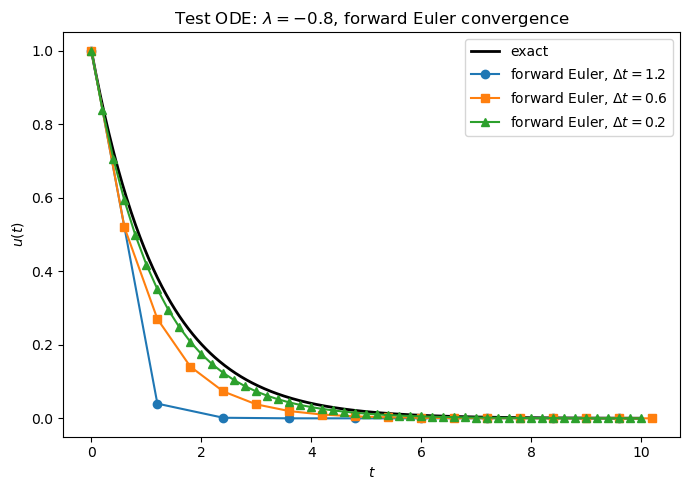

In [5]:
markers = ["o", "s", "^"]

fig, ax = plt.subplots(figsize=(7, 5))

t_fine = np.linspace(0, T, 500)
ax.plot(t_fine, exact_test_ode(c, lam, t_fine), "k-", linewidth=2, label="exact")

for delta_t, marker in zip(delta_ts, markers):
    t, u_fe, err = results[delta_t]
    ax.plot(t, u_fe, marker + "-", label=rf"forward Euler, $\Delta t={delta_t:g}$")

ax.set_xlabel("$t$")
ax.set_ylabel("$u(t)$")
ax.legend()
ax.set_title(rf"Test ODE: $\lambda={lam}$, forward Euler convergence")
fig.tight_layout()

filename = "test_ode_convergence_solution.png"
fig.savefig(filename, dpi=300, bbox_inches="tight")
print(f"saved {filename}")
plt.show()

As $\Delta t$ decreases, the forward Euler solution tracks the exact solution more closely, illustrating
convergence. We can make this more precise by plotting the pointwise absolute error $|u(t_n) - u_n|$
directly.

saved test_ode_convergence_error.png


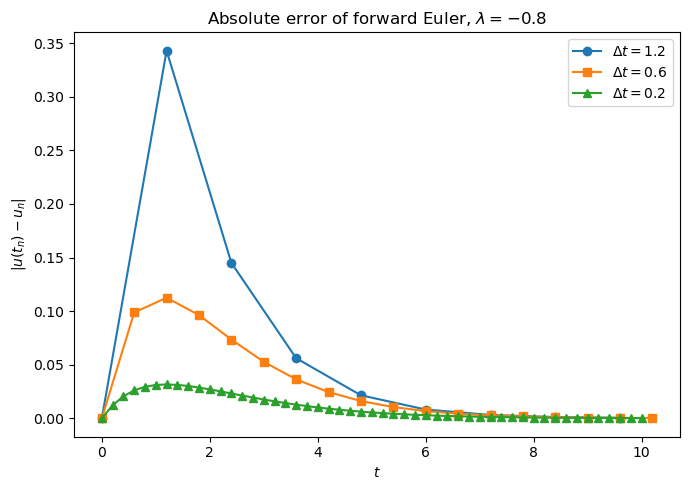

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))

for delta_t, marker in zip(delta_ts, markers):
    t, u_fe, err = results[delta_t]
    ax.plot(t, err, marker + "-", label=rf"$\Delta t={delta_t:g}$")

ax.set_xlabel("$t$")
ax.set_ylabel(r"$|u(t_n) - u_n|$")
ax.legend()
ax.set_title(rf"Absolute error of forward Euler, $\lambda={lam}$")
fig.tight_layout()

filename = "test_ode_convergence_error.png"
fig.savefig(filename, dpi=300, bbox_inches="tight")
print(f"saved {filename}")
plt.show()

On a linear scale the errors for the smaller time steps are hard to compare. Plotting the same
errors with a semilog $y$-axis makes the decay of the error with $\Delta t$ much easier to see.
(The point at $t=0$, where the error is exactly zero, is omitted since $\log 0$ is undefined.)

saved test_ode_convergence_error_semilogy.png


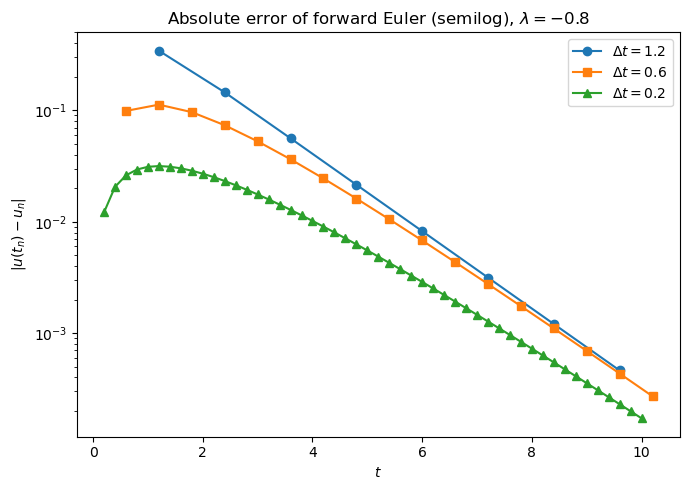

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))

for delta_t, marker in zip(delta_ts, markers):
    t, u_fe, err = results[delta_t]
    # skip n = 0, where the error is exactly zero and undefined on a log scale
    ax.semilogy(t[1:], err[1:], marker + "-", label=rf"$\Delta t={delta_t:g}$")

ax.set_xlabel("$t$")
ax.set_ylabel(r"$|u(t_n) - u_n|$")
ax.legend()
ax.set_title(rf"Absolute error of forward Euler (semilog), $\lambda={lam}$")
fig.tight_layout()

filename = "test_ode_convergence_error_semilogy.png"
fig.savefig(filename, dpi=300, bbox_inches="tight")
print(f"saved {filename}")
plt.show()